# Lasso Regression Baseline

In [ ]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    # Clone your repository if it hasn't been cloned yet
    if not os.path.exists('/content/svi_fema_spatial_graph_modeling'):
        !git clone https://github.com/AnhJoe/svi_fema_spatial_graph_modeling.git

    # Change working directory to the project root
    os.chdir('/content/svi_fema_spatial_graph_modeling')

In [ ]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: /sessions/gifted-gracious-ritchie/mnt/svi_fema_spatial_graph_modeling


In [ ]:
# Standard library
import json

# Third-party libraries
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Local imports
from src.lasso import (
    evaluate_regression,
    get_coefficient_table,
    run_lasso_experiment,
    set_seed,
)

# Plot configuration
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

# Reproducibility
SEED = 42

## Model Motivation

The Lasso (L1-regularized linear) regression serves as a non-neural baseline for predicting county-level disaster assistance outcomes using the log-transformed SVI indicator features. Unlike the MLP and GCN models developed later in this study, Lasso assumes a strictly linear relationship between predictors and the target, and its L1 penalty drives the coefficients of uninformative features toward exactly zero.

This baseline serves two purposes: it establishes a performance floor against which the added complexity of nonlinear and spatial models can be justified, and its sparsity provides a directly interpretable view of which SVI indicators carry the strongest linear association with disaster assistance.

## Model Formulation

Let $X \in \mathbb{R}^{n \times p}$ denote the standardized feature matrix, where $n$ is the number of counties and $p = 15$ is the number of SVI indicator variables after preprocessing and selective log transformation. Let $y \in \mathbb{R}^{n}$ denote the standardized target variable, defined as the log-transformed FEMA Individuals and Households Program assistance amount:

$$
y = \log(1 + \text{FEMA IHP})
$$

Lasso regression estimates a linear coefficient vector $w \in \mathbb{R}^{p}$ and intercept $b$ by minimizing the penalized sum of squared errors

$$
\mathcal{L}(w, b) = \frac{1}{2n}\sum_{i=1}^{n}\left(y_i - (w^\top x_i + b)\right)^2 + \alpha \lVert w \rVert_1
$$

where $\alpha \geq 0$ controls the strength of the $L_1$ penalty. As $\alpha$ increases, more coefficients are driven exactly to zero, yielding an increasingly sparse and interpretable model.

In [ ]:
# Data directories
RAW_DATA_DIR = root / "data" / "raw"
PROCESSED_DATA_DIR = root / "data" / "processed"
ARTIFACT_DIR = root / "data" / "artifacts"

# Do not change row indices beyond this
X_log = pd.read_csv(PROCESSED_DATA_DIR / "X_log.csv")
y_log = pd.read_csv(PROCESSED_DATA_DIR / "y_log.csv")
fips = pd.read_csv(PROCESSED_DATA_DIR / "fips.csv")["FIPS"].astype(str).str.zfill(5)

with open(PROCESSED_DATA_DIR / "feature_titles.json") as f:
    feature_titles_log = json.load(f)

feature_names = list(X_log.columns)

In [ ]:
# Split log-transformed features and target with fips to maintain row indices for downstream models
# (log-transformed pipeline already established as the stronger representation during MLP feature ablation)

# First split: train vs temp (val + test) = 70/30
Xlog_train, Xlog_temp, ylog_train, ylog_temp, fips_train, fips_temp = train_test_split(
    X_log,
    y_log,
    fips,
    test_size=0.30,
    random_state=SEED,
)

# Second split: validation vs test = 15/15
Xlog_val, Xlog_test, ylog_val, ylog_test, fips_val, fips_test = train_test_split(
    Xlog_temp,
    ylog_temp,
    fips_temp,
    test_size=0.50,
    random_state=SEED,
)

split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [Xlog_train.shape[0], Xlog_val.shape[0], Xlog_test.shape[0]],
})

display(split_summary.style.hide(axis="index"))

Dataset,Samples
Train,2198
Validation,471
Test,472


In [ ]:
# Scale X_log and y_log on train only, matching preprocessing used for the MLP/GCN pipelines
scaler_Xlog = StandardScaler()
Xlog_train_scaled = scaler_Xlog.fit_transform(Xlog_train)
Xlog_val_scaled = scaler_Xlog.transform(Xlog_val)
Xlog_test_scaled = scaler_Xlog.transform(Xlog_test)

scaler_ylog = StandardScaler()
ylog_train_scaled = scaler_ylog.fit_transform(ylog_train)
ylog_val_scaled = scaler_ylog.transform(ylog_val)
ylog_test_scaled = scaler_ylog.transform(ylog_test)

## Alpha (Regularization Strength) Ablation

Model selection for Lasso reduces to choosing a single hyperparameter: the L1 regularization strength $\alpha$. A grid of candidate values spanning several orders of magnitude is evaluated in one pass on the validation split, and the configuration with the lowest validation RMSE is carried forward and retrained on the full training set for final test evaluation.

In [ ]:
#| label: tbl-lasso-alpha-ablation
#| tbl-cap: Validation-set alpha ablation results for the Lasso baseline predicting log1p(FEMA IHP).

set_seed(SEED)

alpha_grid = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]

alpha_results = []
for alpha in alpha_grid:
    result = run_lasso_experiment(
        X_train=Xlog_train_scaled,
        y_train=ylog_train_scaled,
        X_eval=Xlog_val_scaled,
        y_eval=ylog_val_scaled,
        alpha=alpha,
        seed=SEED,
        scaler_y=scaler_ylog,
    )
    alpha_results.append(result)

alpha_results_df = pd.DataFrame([
    {
        "Alpha": r["alpha"],
        "Non-zero Coefficients": r["n_nonzero_coef"],
        "Validation RMSE": round(r["rmse"], 6),
        "Validation R²": round(r["r2"], 6),
    }
    for r in alpha_results
])

display(alpha_results_df.style.hide(axis="index"))

best_idx = alpha_results_df["Validation RMSE"].idxmin()
best_alpha = alpha_results_df.loc[best_idx, "Alpha"]
print(f"Best alpha (lowest validation RMSE): {best_alpha}")

Alpha,Non-zero Coefficients,Validation RMSE,Validation R²
0.000300,15,2.548132,0.271758
0.001000,15,2.546990,0.272411
0.003000,15,2.544051,0.274089
0.010000,14,2.537969,0.277556
0.030000,9,2.547365,0.272196
0.100000,4,2.623230,0.228201
0.300000,1,2.824088,0.105484
1.000000,0,2.986008,-0.000032
3.000000,0,2.986008,-0.000032


Best alpha (lowest validation RMSE): 0.01


## Lasso Experimental Results

The alpha ablation identifies **alpha = 0.01** as the best-performing regularization strength on the validation split, retaining 14 of the 15 log-transformed SVI indicators with non-zero coefficients. Very light regularization (alpha <= 0.003) retains all features but does not improve validation RMSE, while stronger regularization progressively zeroes out coefficients and degrades performance; at alpha = 1.0 the model collapses to predicting the training mean (R² = 0). This configuration is retrained on the full training set and evaluated once on the held-out test set.

The final held-out test evaluation shows **test RMSE = 2.56** and **R² = 0.303**, indicating that a purely linear combination of SVI indicators explains roughly **30% of the variance** in `log1p(FEMA IHP)`. The Lasso coefficients remain useful for interpretation: multi-unit housing (log), single-parent households, and minority population share carry the largest standardized weights, broadly consistent with the socioeconomic and housing themes emphasized elsewhere in the SVI framework.

In [ ]:
#| label: tbl-lasso-test-evaluation
#| tbl-cap: Held-out test-set performance for the final Lasso configuration predicting log1p(FEMA IHP).

set_seed(SEED)

final_lasso_result = run_lasso_experiment(
    X_train=Xlog_train_scaled,
    y_train=ylog_train_scaled,
    X_eval=Xlog_test_scaled,
    y_eval=ylog_test_scaled,
    alpha=best_alpha,
    seed=SEED,
    scaler_y=scaler_ylog,
)

final_lasso_model = final_lasso_result["model"]

final_lasso_results = pd.DataFrame([
    {
        "Model": "Lasso",
        "Feature Pipeline": "Log-Transformed Features",
        "Alpha": best_alpha,
        "Non-zero Coefficients": final_lasso_result["n_nonzero_coef"],
        "Test RMSE": round(final_lasso_result["rmse"], 6),
        "Test R²": round(final_lasso_result["r2"], 6),
    }
])

display(final_lasso_results.T.style.hide(axis="columns"))

Model,Lasso
Feature Pipeline,Log-Transformed Features
Alpha,0.010000
Non-zero Coefficients,14
Test RMSE,2.555675
Test R²,0.303201


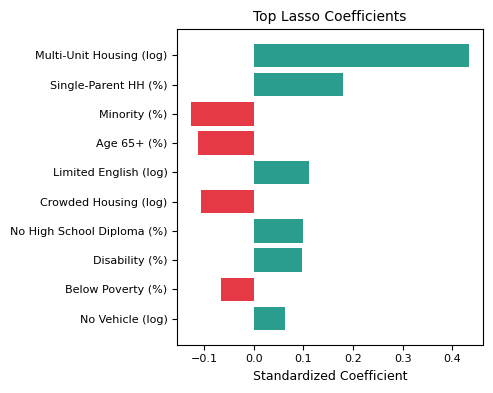

Feature,Feature Label,Coefficient
EP_MUNIT_LOG,Multi-Unit Housing (log),0.433479
EP_SNGPNT,Single-Parent HH (%),0.179070
EP_MINRTY,Minority (%),-0.125920
EP_AGE65,Age 65+ (%),-0.112458
EP_LIMENG_LOG,Limited English (log),0.111641
EP_CROWD_LOG,Crowded Housing (log),-0.106605
EP_NOHSDP,No High School Diploma (%),0.099974
EP_DISABL,Disability (%),0.097754
EP_POV,Below Poverty (%),-0.065066
EP_NOVEH_LOG,No Vehicle (log),0.062631


In [ ]:
#| label: fig-lasso-coefficients
#| fig-cap: Top standardized Lasso coefficients (by absolute magnitude) for predicting log1p(FEMA IHP).

coef_table = get_coefficient_table(final_lasso_model, feature_names)
coef_table["Feature Label"] = coef_table["Feature"].map(feature_titles_log).fillna(coef_table["Feature"])

top_coef = coef_table.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#2a9d8f" if c >= 0 else "#e63946" for c in top_coef["Coefficient"]]
ax.barh(top_coef["Feature Label"], top_coef["Coefficient"], color=colors)
ax.set_xlabel("Standardized Coefficient")
ax.set_title("Top Lasso Coefficients")
plt.tight_layout()
plt.show()

display(coef_table[["Feature", "Feature Label", "Coefficient"]].style.hide(axis="index"))

In [ ]:
#| output: false

# Ensure the output directories exist
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Save final artifact for MLP/GCN comparisons
final_lasso_results.to_csv(ARTIFACT_DIR / "final_lasso_results.csv", index=False)
coef_table.to_csv(ARTIFACT_DIR / "final_lasso_coefficients.csv", index=False)
joblib.dump(final_lasso_model, ARTIFACT_DIR / "final_lasso_model.pkl")

['/sessions/gifted-gracious-ritchie/mnt/svi_fema_spatial_graph_modeling/data/artifacts/final_lasso_model.pkl']

## Summary of Findings

As a linear baseline, Lasso regression explains roughly **30% of the variance** in county-level FEMA IHP assistance using only the 15 SVI indicators. The L1 penalty narrows the feature set to a small number of consistently informative predictors, with housing structure, family composition, minority status, and English proficiency emerging as the strongest linear signals.

That a purely linear, non-spatial model leaves the majority of the variance (roughly 70%) unexplained motivates two directions worth testing directly rather than assuming: whether the relationship between vulnerability indicators and disaster assistance is meaningfully **nonlinear**, which a more flexible model such as a multilayer perceptron (MLP) can evaluate; and whether **geographic proximity** carries predictive signal beyond what county-level indicators alone provide, which a graph-based model such as a GCN can evaluate. This Lasso baseline therefore establishes the linear performance floor against which the added complexity of nonlinear and spatial models should be justified.